# data_brain2 — Image & Mask Inspector
Checks pixel value ranges and renders a grid of image/mask pairs.

In [1]:
import glob, os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

DATA_ROOT = 'data_brain2/kaggle_3m'

# Collect all (image, mask) pairs
mask_paths = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*_mask.tif'), recursive=True))
img_paths  = [p.replace('_mask.tif', '.tif') for p in mask_paths]

print(f'Total pairs found: {len(mask_paths)}')

Total pairs found: 3929


In [2]:
# --- Pixel value diagnostics ---
sample_img  = np.array(Image.open(img_paths[0]))
sample_mask = np.array(Image.open(mask_paths[0]))

print('IMAGE :', sample_img.shape,  sample_img.dtype,  '| min:', sample_img.min(),  '| max:', sample_img.max())
print('MASK  :', sample_mask.shape, sample_mask.dtype, '| min:', sample_mask.min(), '| max:', sample_mask.max())
print('Unique mask values:', np.unique(sample_mask))

IMAGE : (256, 256, 3) uint8 | min: 0 | max: 241
MASK  : (256, 256) uint8 | min: 0 | max: 0
Unique mask values: [0]


In [3]:
def load_display(img_path, mask_path):
    img  = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    # Normalise image for display (handles uint16 or float)
    if img.max() > 255:
        img_disp = (img / img.max() * 255).astype(np.uint8)
    else:
        img_disp = img.astype(np.uint8)

    # Normalise mask for display
    if mask.max() == 1:
        mask_disp = (mask * 255).astype(np.uint8)
    elif mask.max() > 255:
        mask_disp = (mask / mask.max() * 255).astype(np.uint8)
    else:
        mask_disp = mask.astype(np.uint8)

    return img_disp, mask_disp


# Pick 6 pairs that actually contain tumour (non-zero mask)
positive_pairs = [(i, m) for i, m in zip(img_paths, mask_paths)
                  if np.array(Image.open(m)).max() > 0]
print(f'Pairs with tumour mask: {len(positive_pairs)} / {len(mask_paths)}')

samples = positive_pairs[:6] if len(positive_pairs) >= 6 else positive_pairs

Pairs with tumour mask: 1373 / 3929


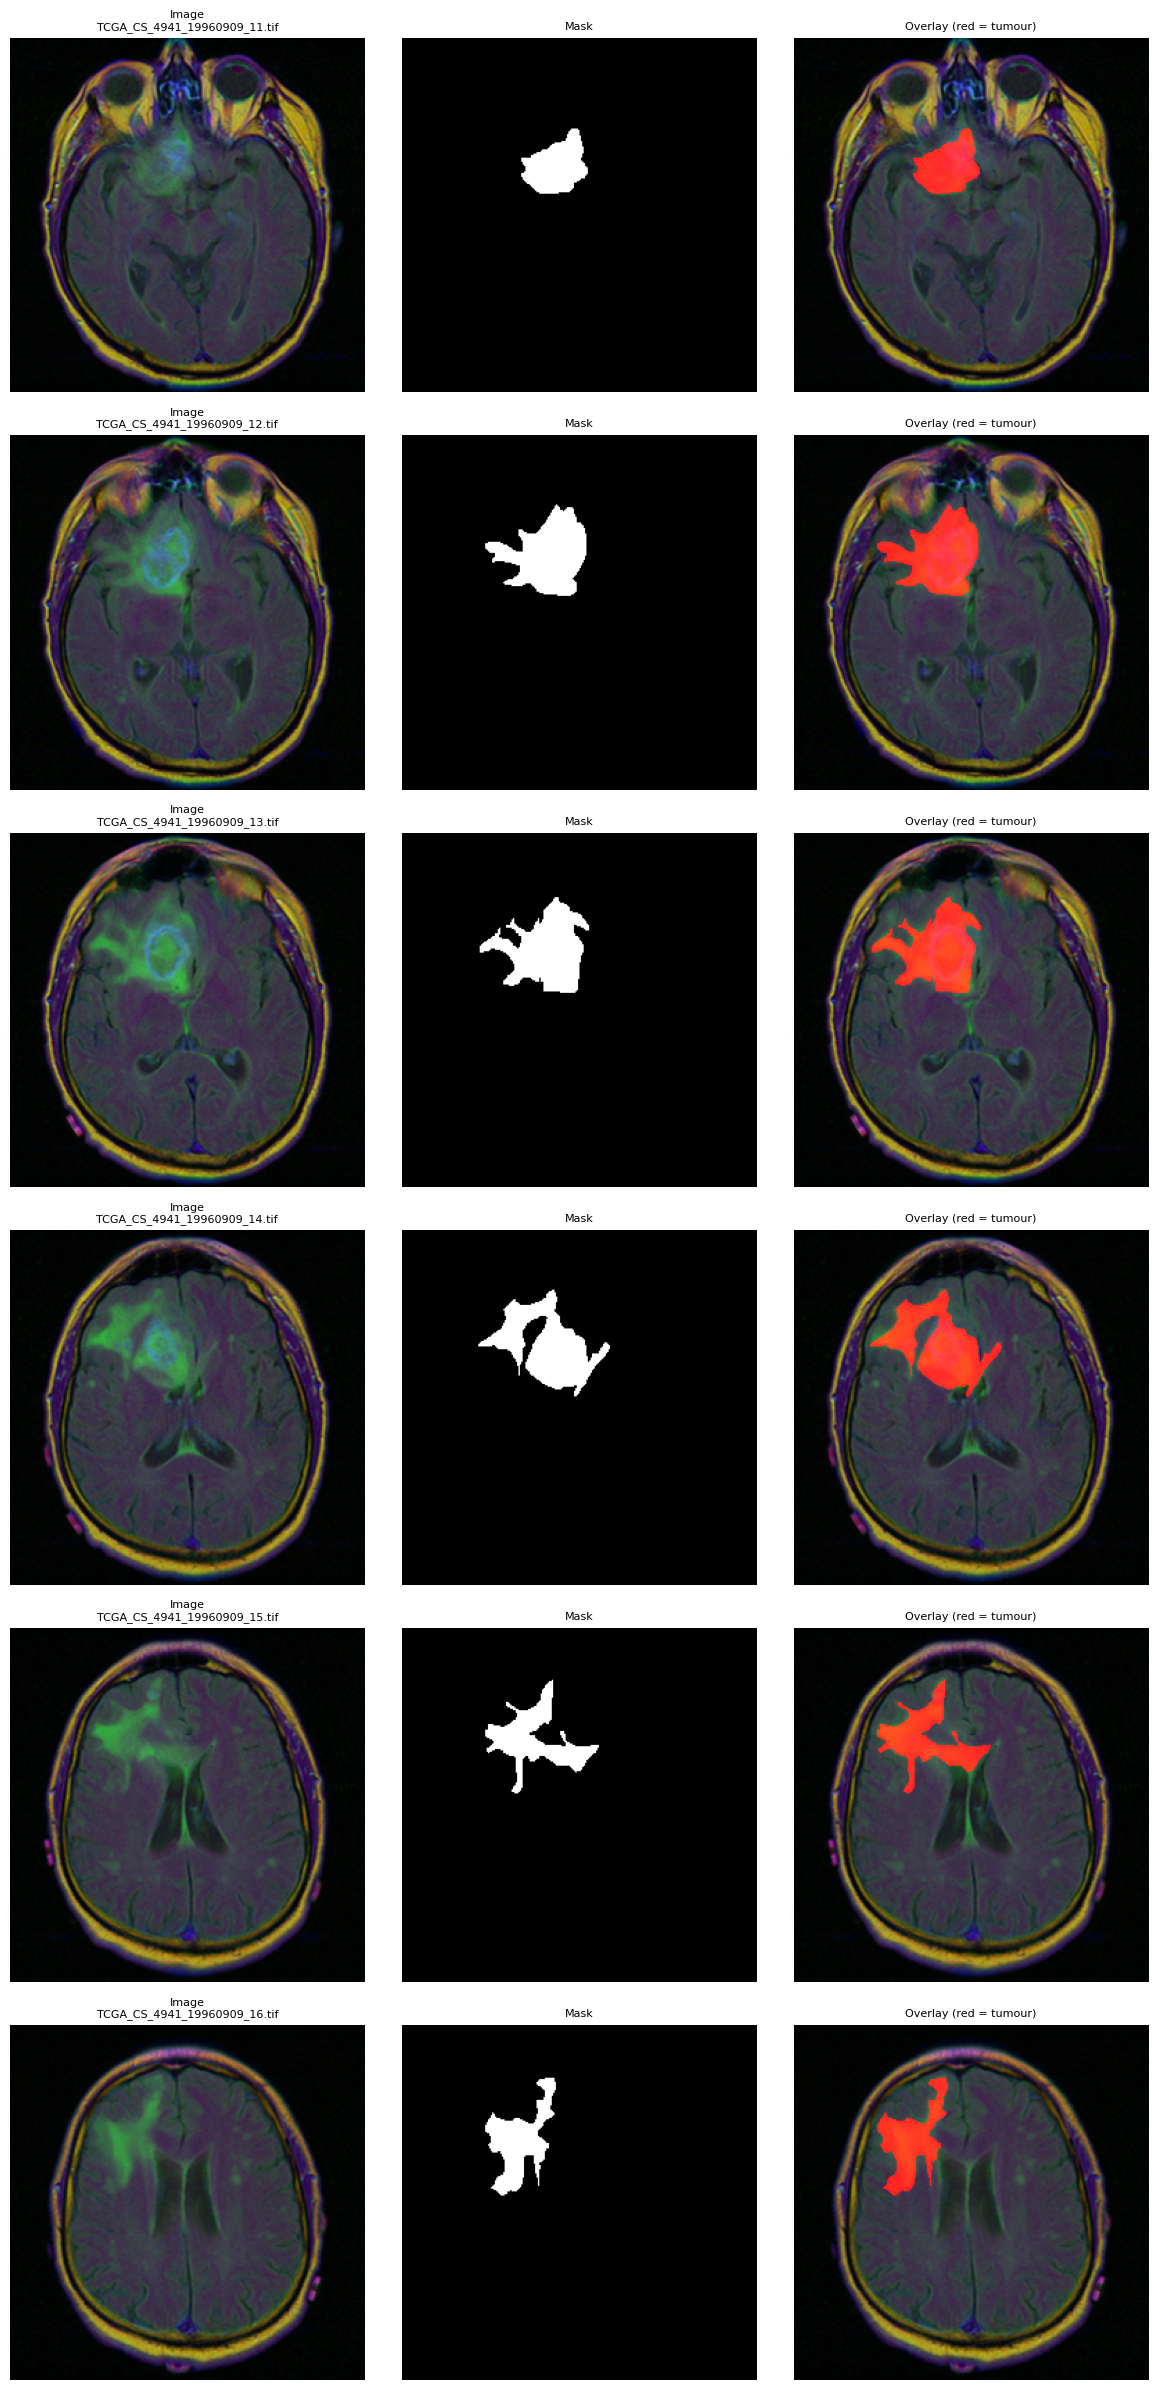

In [4]:
fig, axes = plt.subplots(len(samples), 3, figsize=(12, 4 * len(samples)))
if len(samples) == 1:
    axes = [axes]  # keep iterable

for row, (ip, mp) in enumerate(samples):
    img_disp, mask_disp = load_display(ip, mp)
    name = os.path.basename(ip)

    # Image
    ax = axes[row][0]
    cmap = 'gray' if img_disp.ndim == 2 else None
    ax.imshow(img_disp, cmap=cmap)
    ax.set_title(f'Image\n{name}', fontsize=8)
    ax.axis('off')

    # Mask
    ax = axes[row][1]
    ax.imshow(mask_disp, cmap='gray')
    ax.set_title('Mask', fontsize=8)
    ax.axis('off')

    # Overlay
    ax = axes[row][2]
    if img_disp.ndim == 2:
        base = np.stack([img_disp]*3, axis=-1)
    else:
        base = img_disp[..., :3].copy()
    overlay = base.copy()
    mask_bool = mask_disp > 0
    overlay[mask_bool, 0] = 255   # red channel highlight
    overlay[mask_bool, 1] = overlay[mask_bool, 1] // 2
    overlay[mask_bool, 2] = overlay[mask_bool, 2] // 2
    ax.imshow(overlay)
    ax.set_title('Overlay (red = tumour)', fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.show()